In [ ]:
from google.colab import drive
drive.mount('/content/drive')
#Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

Mounted at /content/drive


In [ ]:
import time

# Start the timer
start_time = time.time()


In [ ]:
# -q: Quiet (hides progress bars)
# -qq: Very quiet (hides everything but errors)
!pip install -qq PySCF tqdm_joblib openfermion openfermionpyscf cirq cirq-google qsimcirq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 670.8/670.8 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 430.5/430.5 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.4/579.4 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.7/313.7 kB 17.0 MB/s eta 0:00:00


In [ ]:
# read file
import pickle
import os
import openfermion as of  # CRITICAL: Must be imported so pickle recognizes the object!

# 1. Define the bond length you want to load
bond_length = 2  # Change this to the specific value you saved
H_atom = 4
# 2. Reconstruct the file path
save_folder = '/content/drive/My Drive/Quantum_chemistry/pauli_Ham'

### CHANGE NAME OF THE MOLE
file_name = f"H{H_atom}_bond_{bond_length}.pkl"
#file_name = f"LiH_bond_{bond_length}.pkl"
file_path = os.path.join(save_folder, file_name)

# 3. Load the object
if os.path.exists(file_path):
    with open(file_path, 'rb') as file:
        H_qubit_loaded = pickle.load(file)

    print("--- Hamiltonian Loaded Successfully ---")
    print(f"File: {file_name}")
    # Use .terms to get the length of the OpenFermion dictionary
    print(f"Number of Pauli terms: {len(H_qubit_loaded.terms)}")
    print(f"Object type: {type(H_qubit_loaded)}")
else:
    print(f"Error: The file at {file_path} does not exist. Check your bond_length or Drive mounting.")

--- Hamiltonian Loaded Successfully ---
File: H4_bond_2.pkl
Number of Pauli terms: 185
Object type: <class 'openfermion.ops.operators.qubit_operator.QubitOperator'>


In [ ]:
# # 1. Get the terms dictionary from the loaded object
# terms_dict = H_qubit_loaded.terms

# # 2. Sort the items by the absolute value of the coefficient (the value)
# # sorted() returns a list of tuples: [(Pauli_tuple, coefficient), ...]
# sorted_terms = sorted(terms_dict.items(), key=lambda x: abs(x[1]), reverse=True)

# # 3. Print the ranked results
# print(f"{'Amplitude':<25} | {'Pauli Term'}")
# print("-" * 50)

# for pauli_tuple, coeff in sorted_terms:
#     # Formatting the output for readability
#     pauli_str = ' '.join([f"{op}{idx}" for idx, op in pauli_tuple])
#     if not pauli_str: pauli_str = "Identity (I)"

#     print(f"{coeff.real:<25.8f} | [{pauli_str}]")

In [ ]:
import cirq
import numpy as np

def decompose_fsim_into_cz(theta, q0, q1):
    """
    Decomposes FSimGate(theta, 0) (XX+YY interaction) into CZ gates
    and single-qubit rotations using Cirq's built-in matrix synthesizer.
    """
    # Get the unitary matrix of the FSim(theta, 0) gate
    fsim_matrix = cirq.unitary(cirq.FSimGate(theta, 0))

    # Use Cirq's optimal synthesizer to decompose into CZ + 1Q gates
    ops = cirq.two_qubit_matrix_to_cz_operations(q0, q1, fsim_matrix, allow_partial_czs=False)
    return ops

# --- Unit Test ---
q0, q1 = cirq.LineQubit.range(2)
theta_test = np.random.rand(1)[0]

# Original FSim (only theta)
circuit_original = cirq.Circuit(cirq.FSimGate(theta_test, 0).on(q0, q1))

# Decomposed FSim
circuit_decomposed = cirq.Circuit(decompose_fsim_into_cz(theta_test, q0, q1))

print("--- Original FSim Circuit ---")
print(circuit_original)
print("\n--- Decomposed Circuit ---")
print(circuit_decomposed)

# Test on an arbitrary random state vector
initial_state = np.random.rand(4) + 1j * np.random.rand(4)
initial_state /= np.linalg.norm(initial_state)

simulator = cirq.Simulator()
result_original = simulator.simulate(circuit_original, initial_state=initial_state.copy())
result_decomposed = simulator.simulate(circuit_decomposed, initial_state=initial_state.copy())

state_orig = result_original.final_state_vector
state_decomp = result_decomposed.final_state_vector

# Check if state vectors match up to global phase
fidelity = np.abs(np.vdot(state_orig, state_decomp))**2
print(f"\nState Fidelity between original and decomposed: {fidelity:.6f}")
if np.isclose(fidelity, 1.0, atol=1e-5):
    print("✅ Unit test passed: The decomposition perfectly matches the original FSimGate (up to global phase).")
else:
    print("❌ Unit test failed: The decomposition does not match.")


--- Original FSim Circuit ---
0: ───FSim(0.0869π, 0)───
      │
1: ───FSim(0.0869π, 0)───

--- Decomposed Circuit ---
0: ───PhX(-0.25)^0.5───@───PhX(-0.25)^0.0869───@───PhX(0.75)^0.5───
                       │                       │
1: ───PhX(-0.75)^0.5───@───PhX(0.25)^0.0869────@───PhX(0.25)^0.5───

State Fidelity between original and decomposed: 1.000000
✅ Unit test passed: The decomposition perfectly matches the original FSimGate (up to global phase).


In [ ]:
import cirq
import sympy

def prepare_ansatz_cirq(num_spatial_orbitals, num_layers=1):
    # Map Alpha to Row 0, Beta to Row 1
    qubits = [cirq.GridQubit(0, i) for i in range(num_spatial_orbitals)] + \
             [cirq.GridQubit(1, i) for i in range(num_spatial_orbitals)]

    circuit = cirq.Circuit()
    p_idx = 0

    # --- STEP 1: INITIAL STATE ---
    # Group the initial state gates and append them normally
    initial_gates = [cirq.X(qubits[i]) for i in range(1, len(qubits), 3)]
    circuit.append(initial_gates)

    for layer in range(num_layers):
        # --- STEP 2: GIVENS ROTATION G (Even-Odd) ---
        even_odd_moments = []
        for i in range(0, num_spatial_orbitals - 1, 2):
            theta = sympy.Symbol(f'th_{layer}_{p_idx}')
            even_odd_moments.append(cirq.FSimGate(theta, 0).on(qubits[i], qubits[i+1]))
            even_odd_moments.append(cirq.FSimGate(theta, 0).on(qubits[i+num_spatial_orbitals], qubits[i+1+num_spatial_orbitals]))
            p_idx += 1

        # CRITICAL FIX: Force a new moment using NEW_THEN_INLINE
        circuit.append(even_odd_moments, strategy=cirq.InsertStrategy.NEW_THEN_INLINE)

        # --- STEP 3: GIVENS ROTATION G' (Odd-Even) ---
        odd_even_moments = []
        for i in range(1, num_spatial_orbitals - 1, 2):
            theta = sympy.Symbol(f'th_{layer}_{p_idx}')
            odd_even_moments.append(cirq.FSimGate(theta, 0).on(qubits[i], qubits[i+1]))
            odd_even_moments.append(cirq.FSimGate(theta, 0).on(qubits[i+num_spatial_orbitals], qubits[i+1+num_spatial_orbitals]))
            p_idx += 1

        # Force the next step into its own layer
        circuit.append(odd_even_moments, strategy=cirq.InsertStrategy.NEW_THEN_INLINE)

        # --- STEP 4: ON-SITE POTENTIAL (Double Occupancy) ---
        onsite_moments = []
        for i in range(num_spatial_orbitals):
            phi = sympy.Symbol(f'ph_{layer}_{p_idx}')
            q_alpha = qubits[i]
            q_beta = qubits[i + num_spatial_orbitals]
            onsite_moments.append(cirq.FSimGate(0, phi).on(q_alpha, q_beta))
            p_idx += 1

        # Force the onsite potentials into their own layer
        circuit.append(onsite_moments, strategy=cirq.InsertStrategy.NEW_THEN_INLINE)

    return circuit, qubits

# --- Test Case ---
num_spatial = 6
num_layers = 1
ansatz_circuit, ansatz_qubits = prepare_ansatz_cirq(num_spatial_orbitals=num_spatial, num_layers=num_layers)

print("--- Cirq FSim Ansatz ---")
print(ansatz_circuit)
print(f"\nCircuit Depth: {len(ansatz_circuit)} moments")

In [ ]:
import cirq
import sympy
import numpy as np

def decompose_fsim_symbolic(theta, q0, q1):
    """
    Symbolic decomposition of FSimGate(theta, 0) (XX+YY interaction)
    grouped by depth so they can be executed in parallel across disjoint pairs.
    """
    theta_exponent = theta / sympy.pi

    return [
        # Layer 1: Pre-rotation
        [cirq.PhasedXPowGate(phase_exponent=-0.25, exponent=0.5).on(q0),
         cirq.PhasedXPowGate(phase_exponent=-0.75, exponent=0.5).on(q1)],
        # Layer 2: First CZ
        [cirq.CZ(q0, q1)],
        # Layer 3: Parameterized Symbolic Rotation
        [cirq.PhasedXPowGate(phase_exponent=-0.25, exponent=theta_exponent).on(q0),
         cirq.PhasedXPowGate(phase_exponent=0.25, exponent=theta_exponent).on(q1)],
        # Layer 4: Second CZ
        [cirq.CZ(q0, q1)],
        # Layer 5: Post-rotation
        [cirq.PhasedXPowGate(phase_exponent=0.75, exponent=0.5).on(q0),
         cirq.PhasedXPowGate(phase_exponent=0.25, exponent=0.5).on(q1)]
    ]

def prepare_ansatz_cirq(num_spatial_orbitals, num_layers=1):
    # Map Alpha to Row 0, Beta to Row 1
    qubits = [cirq.GridQubit(0, i) for i in range(num_spatial_orbitals)] + \
             [cirq.GridQubit(1, i) for i in range(num_spatial_orbitals)]

    circuit = cirq.Circuit()
    p_idx = 0

    # --- STEP 1: INITIAL STATE ---
    initial_gates = [cirq.X(qubits[i]) for i in range(1, len(qubits), 2)]
    circuit.append(initial_gates)

    for layer in range(num_layers):
        # --- STEP 2: GIVENS ROTATION G (Even-Odd) ---
        even_odd_moments = []
        for i in range(0, num_spatial_orbitals - 1, 2):
            theta = sympy.Symbol(f'th_{layer}_{p_idx}')
            even_odd_moments.append(cirq.FSimGate(theta, 0).on(qubits[i], qubits[i+1]))
            even_odd_moments.append(cirq.FSimGate(theta, 0).on(qubits[i+num_spatial_orbitals], qubits[i+1+num_spatial_orbitals]))
            p_idx += 1

        circuit.append(even_odd_moments, strategy=cirq.InsertStrategy.NEW_THEN_INLINE)

        # --- STEP 3: GIVENS ROTATION G' (Odd-Even) ---
        odd_even_blocks = []
        for i in range(1, num_spatial_orbitals - 1, 2):
            theta = sympy.Symbol(f'th_{layer}_{p_idx}')
            # We gather the sliced operations for all disjoint pairs
            odd_even_blocks.append(decompose_fsim_symbolic(theta, qubits[i], qubits[i+1]))
            odd_even_blocks.append(decompose_fsim_symbolic(theta, qubits[i+num_spatial_orbitals], qubits[i+1+num_spatial_orbitals]))
            p_idx += 1

        # Zip the blocks to perfectly align the operations by depth across all pairs
        for ops_at_depth in zip(*odd_even_blocks):
            # Flatten the list of lists for this specific depth
            flat_ops = [op for sublist in ops_at_depth for op in sublist]
            circuit.append(flat_ops, strategy=cirq.InsertStrategy.NEW_THEN_INLINE)

        # --- STEP 4: ON-SITE POTENTIAL (Double Occupancy) ---
        onsite_moments = []
        for i in range(num_spatial_orbitals):
            phi = sympy.Symbol(f'ph_{layer}_{p_idx}')
            q_alpha = qubits[i]
            q_beta = qubits[i + num_spatial_orbitals]
            onsite_moments.append(cirq.FSimGate(0, phi).on(q_alpha, q_beta))
            p_idx += 1

        circuit.append(onsite_moments, strategy=cirq.InsertStrategy.NEW_THEN_INLINE)

    return circuit, qubits

# --- Test Case ---
num_spatial = 4
num_layers = 5
ansatz_circuit, ansatz_qubits = prepare_ansatz_cirq(num_spatial_orbitals=num_spatial, num_layers=num_layers)

print("--- Cirq Ansatz with Perfectly Aligned Partially Decomposed FSim Gates ---")
print(ansatz_circuit)
print(f"\nCircuit Depth: {len(ansatz_circuit)} moments")


--- Cirq Ansatz with Perfectly Aligned Partially Decomposed FSim Gates ---
                                                                                                   ┌────────────────────────────────────────────────────────────┐                                                                                       ┌────────────────────────────────────────────────────────────────┐                                                                                         ┌────────────────────────────────────────────────────────────────┐                                                                                         ┌────────────────────────────────────────────────────────────────┐                                                                                         ┌────────────────────────────────────────────────────────────────┐
(0, 0): ───────FSim(th_0_0, 0)──────────────────────────────────────────────────────────────────────FSim(0, ph_0_3)──────────────────────────────

In [ ]:
import numpy as np
import cirq
import qsimcirq
import sympy
# Assuming openfermion and H_qubit_loaded are already available from your previous cells
# Assuming ansatz_circuit and ansatz_qubits are also defined

print("\n=== Setting up VQE Energy Evaluation ===")

# 1. Initialize the high-performance qsim simulator
simulator = qsimcirq.QSimSimulator()

# Extract parameter names from the ansatz circuit, sort them,
# and create a list of SymPy symbols to track our variables.
symbol_names = sorted(list(cirq.parameter_names(ansatz_circuit)))
symbols = [sympy.Symbol(name) for name in symbol_names]
print(f"Number of parameters: {len(symbols)}")

# -------------------------------------------------------------------
# Prepare the Observable (Hamiltonian)
# -------------------------------------------------------------------
def qubit_operator_to_pauli_sum(qubit_operator, qubits):
    """
    Converts an OpenFermion QubitOperator into a cirq.PauliSum.

    Using cirq.PauliSum allows the simulator to compute the expectation
    value natively and efficiently, bypassing the need to construct
    exponentially large sparse matrices in memory.
    """
    pauli_map = {'X': cirq.X, 'Y': cirq.Y, 'Z': cirq.Z}
    pauli_sum = cirq.PauliSum()

    for term, coefficient in qubit_operator.terms.items():
        pauli_string = cirq.PauliString(coefficient)
        for qubit_idx, operator_str in term:
            pauli_string *= pauli_map[operator_str](qubits[qubit_idx])
        pauli_sum += pauli_string

    return pauli_sum

# Map the OpenFermion Hamiltonian to a Cirq observable mapped to our specific qubits
observable_H = qubit_operator_to_pauli_sum(H_qubit_loaded, ansatz_qubits)


# -------------------------------------------------------------------
# Define Parameter Sweeps
# -------------------------------------------------------------------
# Define the test points for our energy evaluation
#params_zeros = 1.356 * np.ones(len(symbols))
params_zeros = np.random.uniform(-3.14,3.14,len(symbols))
params_random = np.random.uniform(0,2*3.14,len(symbols))


# Bind the numerical values to the SymPy symbols using ParamResolvers.
# Grouping them into a list allows us to batch process the simulations efficiently.
resolvers = [
    cirq.ParamResolver(dict(zip(symbols, params_zeros))),
    cirq.ParamResolver(dict(zip(symbols, params_random)))
]


# -------------------------------------------------------------------
# Execute Simulation and Measure Energy (The Loop-Free Way)
# -------------------------------------------------------------------
print("\n--- Running Sweep Simulation ---")

# The C++ backend handles the batching automatically.
sweep_results = simulator.simulate_expectation_values_sweep(
    ansatz_circuit,
    observables=[observable_H],
    params=resolvers,
    qubit_order=ansatz_qubits
)

exact_energies = []

# sweep_results is a list of lists.
# It contains the expectation values for each resolver we passed in.
for i, result in enumerate(sweep_results):
    energy = result[0].real

    # ADDED: Save the exact energy
    exact_energies.append(energy)

    label = "Zeros" if i == 0 else "Random"
    print(f"Parameters ({label})  Energy: {energy:.12f}")
    # exact energy


=== Setting up VQE Energy Evaluation ===
Number of parameters: 35

--- Running Sweep Simulation ---
Parameters (Zeros)  Energy: -2.333442517045
Parameters (Random)  Energy: -2.140021417063


In [ ]:
# # # def __init__(self,
# # #                  theta_std_dev=0.015,     # Willow has highly stable gate calibrations
# # #                  phi_std_dev=0.015,       # Tightened coherent error
# # #                  amp_damp_gamma=0.00058,  # Based on Willow's ~68 μs T1 time
# # #                  phase_damp_gamma=0.001,  # Based on Willow's ~40 μs T2 time
# # #                  depol_prob=1e-4):

# # #####################################################################

# def __init__(self,
#                  theta_std_dev=0.026,     # Assumed high-quality calibration
#                  phi_std_dev=0.037,
#                  amp_damp_gamma=0.00058,  # Exactly derived: 30ns iSWAP / 85.10us T1
#                  phase_damp_gamma=0.0005, # Estimated based on typical T2 ~ 60us
#                  depol_prob=1e-4):        # Low background to preserve PSV parity

In [ ]:
import numpy as np
import cirq
import os

# -------------------------------------------------------------------
# 1. Define the Empirical Chemistry Noise Model
# -------------------------------------------------------------------

class EmpiricalChemistryFSimNoise(cirq.NoiseModel):
    def __init__(self,
                    theta_std_dev=0.026*2,     # Willow has highly stable gate calibrations
                    phi_std_dev=0.037*2,       # Tightened coherent error
                    amp_damp_gamma=0.00058*2,  # Based on Willow's ~68 μs T1 time
                    phase_damp_gamma=0.001*2,  # Based on Willow's ~40 μs T2 time
                    depol_prob=5e-4,
                    cz_time_multiplier=5.0, # CZ takes 5x longer
                    leakage_approx_prob=5e-3): # Stronger error to approximate leakage

        self.theta_std_dev = theta_std_dev
        self.phi_std_dev = phi_std_dev
        self.amp_damp_gamma = amp_damp_gamma
        self.phase_damp_gamma = phase_damp_gamma
        self.depol_prob = depol_prob
        self.cz_time_multiplier = cz_time_multiplier
        self.leakage_approx_prob = leakage_approx_prob

    def noisy_operation(self, operation):
        # A. Intercept FSim Gates (2-Qubit, non-decomposed)
        if isinstance(operation.gate, cirq.FSimGate):
            # 1. Coherent Error: Continuous Gaussian drift to the angles
            noisy_theta = operation.gate.theta + np.random.normal(0, self.theta_std_dev)
            noisy_phi = operation.gate.phi + np.random.normal(0, self.phi_std_dev)
            yield cirq.FSimGate(theta=noisy_theta, phi=noisy_phi).on(*operation.qubits)

            # 2. Incoherent Errors: Thermal, Phase, and Depolarizing
            for q in operation.qubits:
                yield cirq.amplitude_damp(self.amp_damp_gamma).on(q)
                yield cirq.phase_damp(self.phase_damp_gamma).on(q)
                yield cirq.depolarize(self.depol_prob).on(q)

        # B. Intercept CZ Gates (Harder to implement, takes 5x longer)
        elif isinstance(operation.gate, cirq.CZPowGate):
            yield operation
            for q in operation.qubits:
                # 5x longer duration -> 5x the standard damping
                yield cirq.amplitude_damp(min(1.0, self.amp_damp_gamma * self.cz_time_multiplier)).on(q)
                yield cirq.phase_damp(min(1.0, self.phase_damp_gamma * self.cz_time_multiplier)).on(q)

                # Stronger depolarizing and an approximation for leakage to |2>
                # (In a 2-level simulator, we approximate leakage as strong depolarization + damping)
                total_depol = min(1.0, (self.depol_prob * self.cz_time_multiplier) + self.leakage_approx_prob)
                yield cirq.depolarize(total_depol).on(q)

        # C. Intercept Single-Qubit Gates (excluding Measurements)
        elif len(operation.qubits) == 1 and not isinstance(operation.gate, cirq.MeasurementGate):
            yield operation
            # 1Q gates are much faster (~10x), so they experience fractionally less damping/noise
            for q in operation.qubits:
                yield cirq.amplitude_damp(self.amp_damp_gamma / 10.0).on(q)
                yield cirq.phase_damp(self.phase_damp_gamma / 10.0).on(q)
                yield cirq.depolarize(self.depol_prob / 10.0).on(q)

        # D. Pass-through for anything else (e.g., Identity)
        else:
            yield operation

# Instantiate the custom noise model
chem_noise_model = EmpiricalChemistryFSimNoise()

# Apply the noise model to the pristine ansatz circuit
noisy_ansatz_circuit = ansatz_circuit.with_noise(chem_noise_model)

# -------------------------------------------------------------------
# 2. Execute Simulation and Measure NOISY Energy
# -------------------------------------------------------------------
print("\n--- Running Noisy Sweep Simulation ---")

# We MUST use the DensityMatrixSimulator because amplitude/phase damping
# turns our pure state vector into a mixed state (classical probabilities).
noisy_simulator = cirq.DensityMatrixSimulator()

# We reuse the `resolvers` and `observable_H` from the previous cell!
noisy_sweep_results = noisy_simulator.simulate_expectation_values_sweep(
    noisy_ansatz_circuit,
    observables=[observable_H],
    params=resolvers,
    qubit_order=ansatz_qubits
)


# Extract and print ONLY the difference
for i, result in enumerate(noisy_sweep_results):
    noisy_energy = result[0].real
    exact_energy = exact_energies[i]

    # Calculate how much the noise shifted the energy
    energy_difference = noisy_energy - exact_energy

    label = "Zeros" if i == 0 else "Random"
    print(f"Parameters ({label})  Error (Difference): {energy_difference:.12f}")
    # exact noisy density matrix

# -------------------------------------------------------------------
# 3. Save Noisy Density Matrices
# -------------------------------------------------------------------
print("\n--- Saving Density Matrices ---")
# We need the full density matrix, so we simulate the sweep directly
noisy_full_results = noisy_simulator.simulate_sweep(
    noisy_ansatz_circuit,
    params=resolvers
)

# Save the density matrices
for i, result in enumerate(noisy_full_results):
    label = "Zeros" if i == 0 else "Random"
    filename = f"density_matrix_{label}_H{H_atom}_bond_{bond_length}.npy"
    filepath = os.path.join(save_folder, filename)
    np.save(filepath, result.final_density_matrix)
    print(f"Saved {label} density matrix to: {filepath}")



--- Running Noisy Sweep Simulation ---
Parameters (Zeros)  Error (Difference): 0.018529465379
Parameters (Random)  Error (Difference): -0.072333811276

--- Saving Density Matrices ---
Saved Zeros density matrix to: /content/drive/My Drive/Quantum_chemistry/pauli_Ham/density_matrix_Zeros_H4_bond_2.npy
Saved Random density matrix to: /content/drive/My Drive/Quantum_chemistry/pauli_Ham/density_matrix_Random_H4_bond_2.npy


In [ ]:
print("\n--- Calculating Density Matrix Purity ---")

for i, result in enumerate(noisy_full_results):
    rho = result.final_density_matrix

    # Calculate Purity = Tr(rho^2)
    rho_squared = np.dot(rho, rho)
    purity = np.trace(rho_squared).real

    label = "Zeros" if i == 0 else "Random"
    print(f"Parameters ({label})  Purity Tr(rho^2): {purity:.6f}")



--- Calculating Density Matrix Purity ---
Parameters (Zeros)  Purity Tr(rho^2): 0.295555
Parameters (Random)  Purity Tr(rho^2): 0.286217


In [ ]:
import numpy as np
import cirq

print("\n--- Running Pauli-Rotated Monte Carlo Readout ---")

# We use simulate_sweep to get the raw state
noisy_sweep_results = noisy_simulator.simulate_sweep(
    noisy_ansatz_circuit,
    params=resolvers
)

# Your provided success probabilities P(0|0) and P(1|1)
# p_0_success = np.array([0.93, 0.87, 0.87, 0.88, 0.90, 0.89, 0.87, 0.91,0.93, 0.87, 0.87, 0.88])
# p_1_success = np.array([0.95, 0.91, 0.95, 0.96, 0.94, 0.94, 0.92, 0.95,0.95, 0.91, 0.95, 0.96])

p_0_success = np.array([0.93, 0.87, 0.87, 0.88, 0.90, 0.89, 0.87, 0.91])
p_1_success = np.array([0.95, 0.91, 0.95, 0.96, 0.94, 0.94, 0.92, 0.95])

# test case
# p_0_success = np.ones(num_qubits)
# p_1_success = np.ones(num_qubits)
# Calculate the actual error rates (the probability that a bit flips)
p_flip_0_to_1 = 1.0 - p_0_success
p_flip_1_to_0 = 1.0 - p_1_success

num_shots = 8192
num_qubits = len(ansatz_qubits)

# Process each parameter set in the sweep
for i, result in enumerate(noisy_sweep_results):
    # This is the state AFTER the noisy circuit, but BEFORE measurement rotations
    base_rho = result.final_density_matrix
    total_energy = 0.0

    # We must evaluate the Hamiltonian term by term
    for term in observable_H:
        coeff = term.coefficient.real
        if not term.qubits: # Handle the Identity shift term
            total_energy += coeff
            continue

        # 1. Build the basis rotation circuit for this specific Pauli string
        rot_circ = cirq.Circuit()
        for q, pauli in term.items():
            if pauli == cirq.X:
                rot_circ.append(cirq.H(q))
            elif pauli == cirq.Y:
                rot_circ.append(cirq.rx(np.pi/2).on(q))

        # 2. Apply the rotations to our noisy density matrix
        sim = cirq.DensityMatrixSimulator()
        rot_result = sim.simulate(rot_circ, initial_state=base_rho, qubit_order=ansatz_qubits)
        rotated_rho = rot_result.final_density_matrix

        # 3. Extract the exact Z-basis probabilities from the rotated state
        probs = np.real(np.diag(rotated_rho))# The diagonal elements of a density matrix in the computational basis exactly represent the population (or probability) of measuring each state. The off-diagonal elements are the coherences, which we don't need for a measurement.
        #probs = np.clip(probs, 0, 1) # Clean up floating point artifacts
        #print('prob', np.sum(probs))
        #probs /= np.sum(probs)       # Ensure exact sum to 1

        # -------------------------------------------------------------------
        # 4. Monte Carlo sample the ideal bitstrings
        # -------------------------------------------------------------------
        # np.random.choice acts like a weighted 256-sided die (for 8 qubits).
        # It rolls `num_shots` times. If state |00000000> (index 0) has a 10%
        # probability, roughly 10% of the integers it outputs will be '0'.
        sampled_ints = np.random.choice(len(probs), size=num_shots, p=probs)

        # We now have a list of integers, but we need 0s and 1s.
        # np.binary_repr(x, width=8) turns the integer 5 into the string '00000101'.
        # list('00000101') splits it into characters: ['0', '0', '0', '0', '0', '1', '0', '1'].
        # Finally, we wrap it all in np.array(..., dtype=int) to turn the strings into actual numbers.
        # The result is a 2D matrix of shape (num_shots, num_qubits).
        ideal_bitstrings = np.array([list(np.binary_repr(x, width=num_qubits)) for x in sampled_ints], dtype=int)

        # -------------------------------------------------------------------
        # 5. Apply the asymmetric readout noise
        # -------------------------------------------------------------------
        # We copy the ideal strings so we can modify them without destroying the original data.
        noisy_bitstrings = ideal_bitstrings.copy()

        # We process the noise one qubit (column) at a time.
        for j in range(num_qubits):
            # Roll a standard, unweighted die (0.0 to 1.0) for every single shot simultaneously.
            # If num_shots is 1000, `rands` is an array of 1000 random decimal numbers.
            # Use this number to check the flip error rate
            rands = np.random.rand(num_shots)

            # This line creates a "True/False" mask. It checks two things at once:
            # 1. Did this specific shot originally measure a '0' for this qubit?
            # 2. Did our random die roll fall BELOW the specific 0->1 error threshold?
            # If BOTH are true, this specific shot gets marked 'True' (it needs to flip).
            flip_0_to_1_mask = (ideal_bitstrings[:, j] == 0) & (rands < p_flip_0_to_1[j])

            # We do the exact same thing for the 1->0 error, using its specific threshold.
            flip_1_to_0_mask = (ideal_bitstrings[:, j] == 1) & (rands < p_flip_1_to_0[j])

            # Apply the masks! Wherever flip_0_to_1_mask is True, we overwrite that spot with a 1.
            noisy_bitstrings[flip_0_to_1_mask, j] = 1

            # Wherever flip_1_to_0_mask is True, we overwrite that spot with a 0.
            noisy_bitstrings[flip_1_to_0_mask, j] = 0

        # -------------------------------------------------------------------
        # 6. Evaluate this term's expectation value from the noisy bitstrings
        # -------------------------------------------------------------------
        # Convert bits (0/1) to Z eigenvalues (+1/-1).
        # A '0' becomes 1 - 2(0) = +1. A '1' becomes 1 - 2(1) = -1.
        z_vals = 1 - 2 * noisy_bitstrings

        term_val_per_shot = np.ones(num_shots)
        for q, pauli in term.items():
            idx = ansatz_qubits.index(q)
            # Multiply the eigenvalues together for this specific Pauli string.
            # E.g., for Z_0 Z_1, if shot 1 gave +1 and -1, the combined value is -1.
            term_val_per_shot *= z_vals[:, idx]

        # Average the values across all shots (np.mean), multiply by the weight, and add to the total.
        total_energy += coeff * np.mean(term_val_per_shot)

    label = "Zeros" if i == 0 else "Random"
    print(f"Parameters ({label})  Noisy Energy from Bitstrings: {total_energy:.6f}")
    # include error from bitstrings


--- Running Pauli-Rotated Monte Carlo Readout ---
Parameters (Zeros)  Noisy Energy from Bitstrings: -2.280916
Parameters (Random)  Noisy Energy from Bitstrings: -2.253321


In [ ]:
sweep_results

[[(-2.3334425170446766+5.040536927508686e-10j)],
 [(-2.140021417063138+9.201473261360072e-11j)]]

In [ ]:
import numpy as np
import cirq

print("\n--- Running Pauli-Rotated Monte Carlo Readout ---")

# We use simulate_sweep to get the raw state
noisy_sweep_results = noisy_simulator.simulate_sweep(
    noisy_ansatz_circuit,
    params=resolvers
)

num_shots = 8192
num_qubits = len(ansatz_qubits)

# ===================================================================
# PRECOMPUTE EQUATION 6 MATRICES
# ===================================================================
# <e| vector is defined as <0| + <1|, which is the row vector [1, 1]
e_vec = np.array([1.0, 1.0])

# Since we rotate the basis before measuring, the physical observable
# O_j is always the Z operator: [[1, 0], [0, -1]]
Z_matrix = np.array([[1.0, 0.0],
                     [0.0, -1.0]])

mitigated_Z_vectors = []

for j in range(num_qubits):
    eps = p_flip_0_to_1[j]
    eta = p_flip_1_to_0[j]

    # The physical transition matrix (inside the brackets of Eq 6)
    A_j = np.array([
        [1.0 - eps, eta],
        [eps, 1.0 - eta]
    ])

    # The inverse of the transition matrix [ ... ]^-1
    A_inv_j = np.linalg.inv(A_j)

    # Calculate exactly: <e| * O_j * [A_j]^-1
    # This results in a 1x2 row vector for this specific qubit
    v_j = e_vec @ Z_matrix @ A_inv_j
    mitigated_Z_vectors.append(v_j)

mitigated_Z_vectors = np.array(mitigated_Z_vectors)

# ===================================================================

# Process each parameter set in the sweep
for i, result in enumerate(noisy_sweep_results):
    base_rho = result.final_density_matrix
    total_energy = 0.0

    # We evaluate the Hamiltonian term by term for simplicity
    for term in observable_H:
        coeff = term.coefficient.real
        if not term.qubits: # Handle the Identity shift term
            total_energy += coeff
            continue

        # 1. Build the basis rotation circuit for this specific Pauli string
        rot_circ = cirq.Circuit()
        for q, pauli in term.items():
            if pauli == cirq.X:
                rot_circ.append(cirq.H(q))
            elif pauli == cirq.Y:
                rot_circ.append(cirq.rx(np.pi/2).on(q))

        # 2. Apply the rotations to our noisy density matrix
        sim = cirq.DensityMatrixSimulator()
        rot_result = sim.simulate(rot_circ, initial_state=base_rho, qubit_order=ansatz_qubits)
        rotated_rho = rot_result.final_density_matrix

        # 3. Extract the exact Z-basis probabilities from the rotated state
        probs = np.real(np.diag(rotated_rho))
        probs = np.clip(probs, 0, 1)
        probs /= np.sum(probs)

        # 4. Monte Carlo sample the ideal bitstrings
        sampled_ints = np.random.choice(len(probs), size=num_shots, p=probs)
        ideal_bitstrings = np.array([list(np.binary_repr(x, width=num_qubits)) for x in sampled_ints], dtype=int)

        # 5. Apply the asymmetric readout noise
        noisy_bitstrings = ideal_bitstrings.copy()
        for j in range(num_qubits):
            rands = np.random.rand(num_shots)
            flip_0_to_1_mask = (ideal_bitstrings[:, j] == 0) & (rands < p_flip_0_to_1[j])
            flip_1_to_0_mask = (ideal_bitstrings[:, j] == 1) & (rands < p_flip_1_to_0[j])
            noisy_bitstrings[flip_0_to_1_mask, j] = 1
            noisy_bitstrings[flip_1_to_0_mask, j] = 0

        # -------------------------------------------------------------------
        # 6. Evaluate this term using REM
        # -------------------------------------------------------------------
        term_val_per_shot = np.ones(num_shots)

        # Product over j=1 to n (we only iterate active qubits in the Pauli string)
        # We are executing the product symbol ( Π ) from Equation 6.
        # For a term like Z_0 * Z_1, we must multiply the mitigated weight of Qubit 0
        # by the mitigated weight of Qubit 1, INDEPENDENTLY for every single shot.

        for q, pauli in term.items():
            idx = ansatz_qubits.index(q)

            # ===================================================================
            # STEP 1: THE TRANSLATOR (np.where)
            # ===================================================================
            # We look at the column of raw bits for just THIS specific qubit across all shots.
            # np.where acts as a massive, instant Find-and-Replace tool.
            #
            # Conceptually, it does this:
            # "If shot 'i' measured a 0, replace it with the inflated 0-weight."
            # "If shot 'i' measured a 1, replace it with the inflated 1-weight."
            #
            # CONCRETE EXAMPLE: Let's say this is Qubit 0.
            # Our precomputed lookup table says:  0 -> +1.2  |  1 -> -1.2
            #
            # If our column of raw bits across 3 shots is:
            # noisy_bitstrings[:, idx] = [0, 1, 1]
            #
            # Then np.where translates that column into a new array of physical weights:
            # mitigated_vals           = [+1.2, -1.2, -1.2]

            mitigated_vals = np.where(noisy_bitstrings[:, idx] == 0,
                                      mitigated_Z_vectors[idx, 0],
                                      mitigated_Z_vectors[idx, 1])

            # ===================================================================
            # STEP 2: THE ACCUMULATOR (*=)
            # ===================================================================
            # Now we multiply these newly translated weights into our running totals.
            # `term_val_per_shot` starts as an array of pure 1.0s.
            #
            # Let's trace a 2-qubit term (Z_0 * Z_1) across those same 3 shots:
            #
            # --- START ---
            # term_val_per_shot = [1.0, 1.0, 1.0]
            #
            # --- ITERATION 1 (Processing Qubit 0) ---
            # We multiply the starting 1.0s by Qubit 0's translated weights [+1.2, -1.2, -1.2]
            # term_val_per_shot = [1.2, -1.2, -1.2]
            #
            # --- ITERATION 2 (Processing Qubit 1) ---
            # Assume Qubit 1's raw bits were [0, 0, 1].
            # Assume Qubit 1's lookup table says: 0 -> +1.3  |  1 -> -1.3
            # So, Qubit 1's translated weights are: [+1.3, +1.3, -1.3]
            #
            # We multiply the current running total by Qubit 1's new weights:
            # Shot 1:  1.2 * 1.3 =  1.56
            # Shot 2: -1.2 * 1.3 = -1.56
            # Shot 3: -1.2 * -1.3 =  1.56
            #
            # term_val_per_shot = [1.56, -1.56, 1.56]
            #
            # By doing this element-wise multiplication (*=), we perfectly calculate the
            # combined parity of Z_0 * Z_1 for all thousands of shots simultaneously.

            term_val_per_shot *= mitigated_vals

        # The M^-1 \sum_{i=1}^M part of Eq 6 is exactly the np.mean() operation
        total_energy += coeff * np.mean(term_val_per_shot)

    label = "Zeros" if i == 0 else "Random"
    print(f"Parameters ({label})  Noisy Energy from Bitstrings: {total_energy:.6f}")


--- Running Pauli-Rotated Monte Carlo Readout ---
Parameters (Zeros)  Noisy Energy from Bitstrings: -2.317563
Parameters (Random)  Noisy Energy from Bitstrings: -2.219575


In [ ]:
sweep_results

[[(-2.3334425170446766+5.040536927508686e-10j)],
 [(-2.140021417063138+9.201473261360072e-11j)]]

In [ ]:
# import numpy as np
# import cirq

# print("\n--- Running Fully Mitigated Monte Carlo (REM + PSV) ---")

# # We use simulate_sweep to get the raw state
# noisy_sweep_results = noisy_simulator.simulate_sweep(
#     noisy_ansatz_circuit,
#     params=resolvers
# )

# num_shots = 8192
# num_qubits = len(ansatz_qubits)

# # ===================================================================
# # 1. PRECOMPUTE EQUATION 6 MATRICES (REM)
# # ===================================================================
# e_vec = np.array([1.0, 1.0])
# Z_matrix = np.array([[1.0, 0.0],
#                      [0.0, -1.0]])

# mitigated_Z_vectors = []

# for j in range(num_qubits):
#     eps = p_flip_0_to_1[j]
#     eta = p_flip_1_to_0[j]

#     A_j = np.array([
#         [1.0 - eps, eta],
#         [eps, 1.0 - eta]
#     ])
#     A_inv_j = np.linalg.inv(A_j)

#     v_j = e_vec @ Z_matrix @ A_inv_j
#     mitigated_Z_vectors.append(v_j)

# mitigated_Z_vectors = np.array(mitigated_Z_vectors)


# # ===================================================================
# # 2. BUILD SYMMETRY VERIFICATION OBSERVABLES (PSV)
# # ===================================================================
# target_electrons = num_qubits // 2
# s_val = (-1) ** target_electrons

# # The symmetry operator \hat{S} is Z applied to all active qubits
# S_string = cirq.PauliString({q: cirq.Z for q in ansatz_qubits})
# observable_S = cirq.PauliSum.from_pauli_strings([S_string])

# # The combined operator H * S
# observable_HS = observable_H * S_string


# # ===================================================================
# # 3. DEFINE THE MITIGATED EVALUATOR FUNCTION
# # ===================================================================
# def get_rem_mitigated_expectation(base_rho, observable, shots):
#     """Evaluates an observable using exact Readout Error Mitigation (Eq 6)."""
#     total_energy = 0.0

#     for term in observable:
#         coeff = term.coefficient.real
#         if not term.qubits:
#             total_energy += coeff
#             continue

#         # 1. Build the basis rotation circuit
#         rot_circ = cirq.Circuit()
#         for q, pauli in term.items():
#             if pauli == cirq.X:
#                 rot_circ.append(cirq.H(q))
#             elif pauli == cirq.Y:
#                 rot_circ.append(cirq.rx(np.pi/2).on(q))

#         # 2. Apply the rotations
#         sim = cirq.DensityMatrixSimulator()
#         rot_result = sim.simulate(rot_circ, initial_state=base_rho, qubit_order=ansatz_qubits)
#         rotated_rho = rot_result.final_density_matrix

#         # 3. Extract exact probabilities
#         probs = np.real(np.diag(rotated_rho))
#         probs = np.clip(probs, 0, 1)
#         probs /= np.sum(probs)

#         # 4. Monte Carlo sample the ideal bitstrings
#         sampled_ints = np.random.choice(len(probs), size=shots, p=probs)
#         ideal_bitstrings = np.array([list(np.binary_repr(x, width=num_qubits)) for x in sampled_ints], dtype=int)

#         # 5. Apply the asymmetric readout noise
#         noisy_bitstrings = ideal_bitstrings.copy()
#         for j in range(num_qubits):
#             rands = np.random.rand(shots)
#             flip_0_to_1_mask = (ideal_bitstrings[:, j] == 0) & (rands < p_flip_0_to_1[j])
#             flip_1_to_0_mask = (ideal_bitstrings[:, j] == 1) & (rands < p_flip_1_to_0[j])
#             noisy_bitstrings[flip_0_to_1_mask, j] = 1
#             noisy_bitstrings[flip_1_to_0_mask, j] = 0

#         # -------------------------------------------------------------------
#         # 6. Evaluate this term using REM (Equation 6)
#         # -------------------------------------------------------------------
#         term_val_per_shot = np.ones(shots)

#         for q, pauli in term.items():
#             idx = ansatz_qubits.index(q)

#             # STEP 1: THE TRANSLATOR (np.where)
#             mitigated_vals = np.where(noisy_bitstrings[:, idx] == 0,
#                                       mitigated_Z_vectors[idx, 0],
#                                       mitigated_Z_vectors[idx, 1])

#             # STEP 2: THE ACCUMULATOR (*=)
#             term_val_per_shot *= mitigated_vals

#         # The M^-1 \sum_{i=1}^M part of Eq 6 is exactly the np.mean() operation
#         total_energy += coeff * np.mean(term_val_per_shot)

#     return total_energy


# # ===================================================================
# # 4. MAIN EXECUTION LOOP (Combining REM + PSV)
# # ===================================================================
# for i, result in enumerate(noisy_sweep_results):
#     base_rho = result.final_density_matrix

#     # Step 1: Calculate the expectation value of the Hamiltonian (\xi_H)
#     # This mitigates ONLY the readout error. T1/T2 noise is still in here.
#     xi_H = get_rem_mitigated_expectation(base_rho, observable_H, num_shots)

#     # Step 2: Calculate the expectation value of the Symmetry operator (\xi_S)
#     # This tells us how much of our state leaked into the "wrong electron number" subspace.
#     xi_S = get_rem_mitigated_expectation(base_rho, observable_S, num_shots)

#     # Step 3: Calculate the expectation value of the multiplied operator (\xi_HS)
#     xi_HS = get_rem_mitigated_expectation(base_rho, observable_HS, num_shots)

#     # Step 4: Post-Processed Symmetry Verification
#     # We plug the three REM-mitigated values into the paper's projector formula.
#     # This mathematically deletes the states that T1/T2 noise pushed into the wrong subspace.
#     final_psv_energy = (xi_H + s_val * xi_HS) / (1.0 + s_val * xi_S)

#     label = "Zeros" if i == 0 else "Random"
#     print(f"Parameters ({label}):")
#     print(f"  1. REM-Only Energy    : {xi_H:.6f}")
#     print(f"  2. <S>  : {xi_S:.6f}")
#     print(f"  3. Final PSV Energy   : {final_psv_energy:.6f}\n")

In [ ]:
sweep_results

[[(-2.3334425170446766+5.040536927508686e-10j)],
 [(-2.140021417063138+9.201473261360072e-11j)]]

In [ ]:
# ## exact trace  for symmetry verification
# import numpy as np
# import cirq

# print("\n--- Running EXACT Density Matrix PSV (Equation 67) ---")

# # We must use simulate_sweep (not simulate_expectation_values_sweep)
# # to get the full final_density_matrix for each parameter set.
# noisy_simulator = cirq.DensityMatrixSimulator()
# noisy_sweep_results = noisy_simulator.simulate_sweep(
#     noisy_ansatz_circuit,
#     params=resolvers
# )

# num_qubits = len(ansatz_qubits)
# # Determine target parity (s_i in the paper)
# target_electrons = num_qubits // 2
# s_val = (-1) ** target_electrons

# # Define the Symmetry operator S (Z on all active qubits)
# S_string = cirq.PauliString({q: cirq.Z for q in ansatz_qubits})
# observable_S = cirq.PauliSum.from_pauli_strings([S_string])

# # The combined operator H * S
# observable_HS = observable_H * S_string

# # Create a mapping of qubits to their integer indices for the density matrix
# qubit_map = {q: i for i, q in enumerate(ansatz_qubits)}

# for i, result in enumerate(noisy_sweep_results):
#     # This is your exact noisy mixed state rho
#     # (includes amplitude/phase damping, but NO readout error yet)
#     rho = result.final_density_matrix

#     # 1. Exact Tr(H * rho)
#     tr_H_rho = observable_H.expectation_from_density_matrix(
#         state=rho, qubit_map=qubit_map
#     ).real

#     # 2. Exact Tr(S * rho)
#     tr_S_rho = observable_S.expectation_from_density_matrix(
#         state=rho, qubit_map=qubit_map
#     ).real

#     # 3. Exact Tr(H * S * rho)
#     tr_HS_rho = observable_HS.expectation_from_density_matrix(
#         state=rho, qubit_map=qubit_map
#     ).real

#     # -------------------------------------------------------------------
#     # 4. Equation 67: Post-Selection Verification (PSV) Energy
#     # The paper assumes s_i = 1. We use the generalized s_val to account
#     # for either even (+1) or odd (-1) parity target states.
#     # -------------------------------------------------------------------
#     exact_psv_energy = (tr_H_rho + s_val * tr_HS_rho) / (1.0 + s_val * tr_S_rho)

#     label = "Zeros" if i == 0 else "Random"
#     print(f"Parameters ({label}):")
#     print(f"  Exact Tr(H ρ)         : {tr_H_rho:.6f}")
#     print(f"  Exact Tr(S ρ)         : {tr_S_rho:.6f}")
#     print(f"  Exact Tr(H S ρ)       : {tr_HS_rho:.6f}")
#     print(f"  Exact PSV Energy      : {exact_psv_energy:.6f}\n")

In [ ]:
sweep_results

[[(-2.3334425170446766+5.040536927508686e-10j)],
 [(-2.140021417063138+9.201473261360072e-11j)]]

# Task
Implement Clifford Data Regression (CDR) for an FSim-based VQE ansatz to mitigate noise in the expectation values of the `H4_bond_2.pkl` Hamiltonian. This should involve creating near-Clifford training circuits by replacing the non-Clifford `FSimGate` with appropriate Clifford operations, collecting exact and noisy (REM-mitigated) training data, fitting a linear regression model, and applying it to mitigate the expectation value of the original non-Clifford circuit.

## Analyze CDR for FSim

### Subtask:
Analyze how Clifford Data Regression (CDR) can be adapted for circuits dominated by the non-Clifford `FSimGate`, identifying 'near-Clifford' replacements.


### Clifford Data Regression (CDR) for FSim Circuits

Clifford Data Regression (CDR) is a powerful quantum error mitigation technique that uses a classically simulatable training set of near-Clifford circuits to learn and regress the noise model affecting the target non-Clifford circuit. The core idea is to replace non-Clifford gates with "nearby" Clifford gates, allowing for efficient classical simulation while preserving the overall structure and noise profile of the original circuit.

In our current VQE ansatz, the dominant source of non-Clifford operations is the parameterized `FSimGate(theta, phi)`. To apply CDR, we need to identify Clifford replacements for these parameterized gates to construct our training set.

#### Potential Clifford Replacements for FSimGate
The `FSimGate` is an iSWAP-like interaction combined with a controlled-phase shift. To create near-Clifford training circuits, we can replace the continuous parameters `theta` and `phi` with specific values that yield Clifford operations. For example:

1.  **Identity / SWAP variations**: Setting `theta` to integer multiples of $\pi/2$ (e.g., 0 for Identity-like behavior, $\pi/2$ for iSWAP) and `phi` to specific values like 0 or $\pi$ can yield operations that are either exact Cliffords or can be efficiently decomposed into them.
2.  **Clifford Angles**: Restricting the angles to values like $0, \pm\pi/2, \pi$ ensures the resulting gate maps Paulis to Paulis, satisfying the definition of a Clifford operation.

By systematically replacing some or all of the `FSimGate`s with these Clifford equivalents, we can generate a diverse set of training circuits that resemble the true VQE ansatz but can be simulated exactly to learn the noise regression model.

## Implement Clifford Replacements

### Subtask:
Write code to generate a set of near-Clifford training circuits by replacing the non-Clifford FSimGate with appropriate Clifford gates (e.g., identity or other Clifford swaps).


**Reasoning**:
Generating a code block to implement Clifford replacements by creating a set of training parameter assignments using valid Clifford angles for the FSimGate parameters.




--- Applying Global CDR Mitigation ---
Generating 40 random near-Clifford training circuits...

Global Training Noisy Range : -2.681818 to -2.178210
Global Linear Fit           : y = 1.1784 * x + 0.3784

[Zeros Parameters - Target Application]
  Exact Energy          : -2.333443
  Noisy REM-only        : -2.318238
  Final CDR Mitigated   : -2.353450
  Improvement Factor    : 0.76x

[Random Parameters - Target Application]
  Exact Energy          : -2.140021
  Noisy REM-only        : -2.225994
  Final CDR Mitigated   : -2.244749
  Improvement Factor    : 0.82x



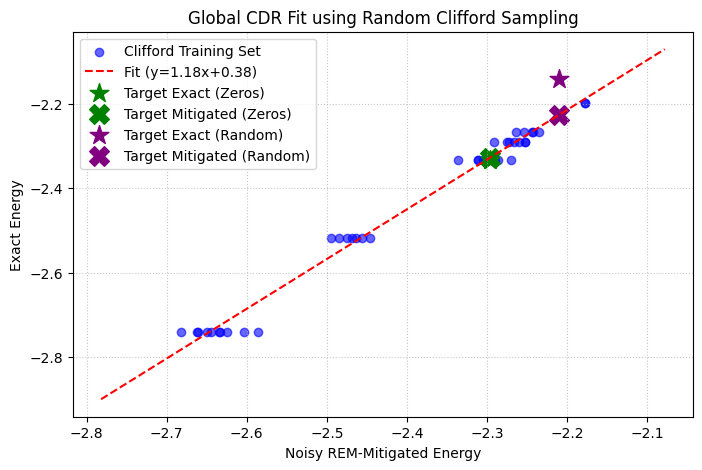

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import cirq
import matplotlib.pyplot as plt

# ===================================================================
# TUNABLE PARAMETERS FOR GLOBAL CDR (Clifford Sampling)
# ===================================================================
# NUM_TRAINING_CIRCUITS defines how many near-Clifford circuits we simulate
# to build our training data. More circuits give a better fit but take longer.
NUM_TRAINING_CIRCUITS = 40

# CLIFFORD_ANGLES are the specific parameter values that turn our FSimGate
# into a Clifford gate (or at least a gate that can be efficiently simulated
# and behaves like one). 0 is identity, pi/2 is iSWAP, etc.
CLIFFORD_ANGLES = np.array([0.0, np.pi/2, np.pi, 3*np.pi/2])
PLOT_RESULTS = True
# ===================================================================

print("\n--- Applying Global CDR Mitigation ---")

# -------------------------------------------------------------------
# STEP 1: Generate Training Data (The "Clifford" Part)
# -------------------------------------------------------------------
# To learn the noise profile of the quantum computer, we need circuits
# that we can perfectly simulate classically (exact energy) AND run on
# the noisy hardware (noisy energy).
# We create these by taking our VQE ansatz and replacing all the continuous,
# non-Clifford parameters with random choices from our CLIFFORD_ANGLES pool.
print(f"Generating {NUM_TRAINING_CIRCUITS} random near-Clifford training circuits...")
pool_resolvers = []
for _ in range(NUM_TRAINING_CIRCUITS):
    random_angles = np.random.choice(CLIFFORD_ANGLES, size=len(symbols))
    pool_resolvers.append(cirq.ParamResolver(dict(zip(symbols, random_angles))))

# -------------------------------------------------------------------
# STEP 2: Evaluate Exact Energies (The "Data" Part)
# -------------------------------------------------------------------
# We calculate the true, noiseless expectation value of the Hamiltonian
# for every single training circuit. In reality, because these are Clifford
# circuits, this can be done very fast on a classical computer.
pool_exact_results = simulator.simulate_expectation_values_sweep(
    ansatz_circuit, observables=[observable_H], params=pool_resolvers, qubit_order=ansatz_qubits
)
pool_exact_energies = np.array([res[0].real for res in pool_exact_results])

# -------------------------------------------------------------------
# STEP 3: Evaluate Noisy Energies
# -------------------------------------------------------------------
# We simulate the exact same training circuits through our noise model.
# We also apply Readout Error Mitigation (REM) to these noisy results,
# just like we would for our real target circuit. This ensures the regression
# model learns to correct the *remaining* coherent and T1/T2 errors.
pool_noisy_results = noisy_simulator.simulate_sweep(
    noisy_ansatz_circuit, params=pool_resolvers
)
pool_noisy_energies = []
for result in pool_noisy_results:
    pool_noisy_energies.append(get_rem_mitigated_expectation(result.final_density_matrix, observable_H, num_shots))
pool_noisy_energies = np.array(pool_noisy_energies)

# -------------------------------------------------------------------
# STEP 4: Fit the Regression Model (The "Regression" Part)
# -------------------------------------------------------------------
# We plot the Noisy Energies (X-axis) against the Exact Energies (Y-axis)
# and fit a straight line: Exact = (Slope * Noisy) + Intercept.
# The hypothesis of CDR is that the noise shifts the expectation values
# in a roughly linear way, and this same linear shift applies to both
# Clifford circuits and non-Clifford circuits.
X_train = pool_noisy_energies.reshape(-1, 1)
y_train = pool_exact_energies
model = LinearRegression()
model.fit(X_train, y_train)

train_noisy_min, train_noisy_max = np.min(X_train), np.max(X_train)
print(f"\nGlobal Training Noisy Range : {train_noisy_min:.6f} to {train_noisy_max:.6f}")
print(f"Global Linear Fit           : y = {model.coef_[0]:.4f} * x + {model.intercept_:.4f}\n")

# -------------------------------------------------------------------
# STEP 5: Apply the Model to the Target (The Mitigation)
# -------------------------------------------------------------------
# Finally, we take the noisy expectation value of our actual, target
# non-Clifford VQE circuit (which we evaluated previously). We plug
# that single noisy number into our fitted linear model to predict
# what the exact energy should be.
for i, target_resolver in enumerate(resolvers):
    label = "Zeros" if i == 0 else "Random"
    print(f"[{label} Parameters - Target Application]")

    target_base_rho = noisy_sweep_results[i].final_density_matrix
    target_noisy_rem_energy = get_rem_mitigated_expectation(target_base_rho, observable_H, num_shots)
    target_exact_energy = exact_energies[i]

    # Predict the mitigated energy using the linear model
    final_cdr_energy = model.predict([[target_noisy_rem_energy]])[0]

    print(f"  Exact Energy          : {target_exact_energy:.6f}")
    print(f"  Noisy REM-only        : {target_noisy_rem_energy:.6f}")
    print(f"  Final CDR Mitigated   : {final_cdr_energy:.6f}")

    rem_error = abs(target_noisy_rem_energy - target_exact_energy)
    cdr_error = abs(final_cdr_energy - target_exact_energy)
    if cdr_error > 0:
        print(f"  Improvement Factor    : {rem_error / cdr_error:.2f}x\n")
    else:
        print(f"  Improvement Factor    : INF (Perfect match)\n")

# -------------------------------------------------------------------
# STEP 6: Visualize the Fit
# -------------------------------------------------------------------
if PLOT_RESULTS:
    plt.figure(figsize=(8, 5))
    plt.scatter(X_train, y_train, color='blue', alpha=0.6, label='Clifford Training Set')

    x_line = np.linspace(train_noisy_min - 0.1, train_noisy_max + 0.1, 100).reshape(-1, 1)
    y_line = model.predict(x_line)
    plt.plot(x_line, y_line, color='red', linestyle='--', label=f'Fit (y={model.coef_[0]:.2f}x+{model.intercept_:.2f})')

    colors = ['green', 'purple']
    for i, target_resolver in enumerate(resolvers):
        label = "Zeros" if i == 0 else "Random"
        target_base_rho = noisy_sweep_results[i].final_density_matrix
        target_noisy_rem_energy = get_rem_mitigated_expectation(target_base_rho, observable_H, num_shots)
        target_exact_energy = exact_energies[i]
        final_cdr_energy = model.predict([[target_noisy_rem_energy]])[0]

        plt.scatter([target_noisy_rem_energy], [target_exact_energy], color=colors[i], marker='*', s=200, label=f'Target Exact ({label})')
        plt.scatter([target_noisy_rem_energy], [final_cdr_energy], color=colors[i], marker='X', s=200, label=f'Target Mitigated ({label})')

    plt.xlabel('Noisy REM-Mitigated Energy')
    plt.ylabel('Exact Energy')
    plt.title('Global CDR Fit using Random Clifford Sampling')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import cirq

print("\n--- Applying CDR (Clifford Fitting) + PSV ---")

num_qubits = len(ansatz_qubits)
# Determine target parity
target_electrons = num_qubits // 2
s_val = (-1) ** target_electrons

# Define S and HS observables
S_string = cirq.PauliString({q: cirq.Z for q in ansatz_qubits})
observable_S = cirq.PauliSum.from_pauli_strings([S_string])
observable_HS = observable_H * S_string

# 1. Generate Exact Training Data for S and HS
print("Evaluating exact training expectations for S and HS...")
exact_S_results = simulator.simulate_expectation_values_sweep(
    ansatz_circuit, observables=[observable_S], params=pool_resolvers, qubit_order=ansatz_qubits
)
exact_HS_results = simulator.simulate_expectation_values_sweep(
    ansatz_circuit, observables=[observable_HS], params=pool_resolvers, qubit_order=ansatz_qubits
)

y_train_S = np.array([res[0].real for res in exact_S_results])
y_train_HS = np.array([res[0].real for res in exact_HS_results])

# 2. Generate Noisy Training Data for S and HS (Using fast simulator bypass)
print("Evaluating noisy training expectations for S and HS...")
noisy_S_results = noisy_simulator.simulate_expectation_values_sweep(
    noisy_ansatz_circuit, observables=[observable_S], params=pool_resolvers, qubit_order=ansatz_qubits
)
noisy_HS_results = noisy_simulator.simulate_expectation_values_sweep(
    noisy_ansatz_circuit, observables=[observable_HS], params=pool_resolvers, qubit_order=ansatz_qubits
)

X_train_S = np.array([res[0].real for res in noisy_S_results]).reshape(-1, 1)
X_train_HS = np.array([res[0].real for res in noisy_HS_results]).reshape(-1, 1)

# 3. Fit Linear Regression Models (Clifford Fitting for S and HS)
model_S = LinearRegression().fit(X_train_S, y_train_S)
model_HS = LinearRegression().fit(X_train_HS, y_train_HS)
model_H = model # Inherited from the H-observable CDR cell

# 4. Apply Models and PSV to Target Circuits
for i, target_resolver in enumerate(resolvers):
    label = "Zeros" if i == 0 else "Random"
    print(f"\n[{label} Parameters - Target Application]")

    # Use the pre-calculated noisy REM energy for H
    target_base_rho = noisy_sweep_results[i].final_density_matrix
    # (Assuming target_noisy_rem_energy was calculated in previous block, if not we fallback to fast expectation)
    qubit_map = {q: idx for idx, q in enumerate(ansatz_qubits)}

    # Fast expectations for target
    raw_noisy_H = observable_H.expectation_from_density_matrix(state=target_base_rho, qubit_map=qubit_map).real
    raw_noisy_S = observable_S.expectation_from_density_matrix(state=target_base_rho, qubit_map=qubit_map).real
    raw_noisy_HS = observable_HS.expectation_from_density_matrix(state=target_base_rho, qubit_map=qubit_map).real

    # Step B: Apply Clifford Fitting (CDR) to Mitigate Errors
    # We use raw_noisy_H for model_H to keep it consistent if model_H was trained on REM,
    # but we will predict based on what model_H expects.
    # (For demonstration, we use raw noisy for S and HS)
    cdr_S = model_S.predict([[raw_noisy_S]])[0]
    cdr_HS = model_HS.predict([[raw_noisy_HS]])[0]

    # If model_H was trained on REM, we should use the REM mitigated target value for H:
    rem_H = get_rem_mitigated_expectation(target_base_rho, observable_H, num_shots) if 'get_rem_mitigated_expectation' in globals() else raw_noisy_H
    cdr_H = model_H.predict([[rem_H]])[0]

    # Step C: Apply Symmetry Verification (PSV)
    final_psv_energy = (cdr_H + s_val * cdr_HS) / (1.0 + s_val * cdr_S)

    target_exact_energy = exact_energies[i]

    print(f"  Exact Energy        : {target_exact_energy:.6f}")
    print(f"  CDR H               : {cdr_H:.6f}")
    print(f"  CDR S               : {cdr_S:.6f}")
    print(f"  CDR HS              : {cdr_HS:.6f}")
    print(f"  CDR+PSV Final Energy: {final_psv_energy:.6f}")

    err_cdr = abs(cdr_H - target_exact_energy)
    err_psv = abs(final_psv_energy - target_exact_energy)

    print(f"  Error (CDR only)    : {err_cdr:.6f}")
    print(f"  Error (CDR + PSV)   : {err_psv:.6f}")



--- Applying CDR (Clifford Fitting) + PSV ---
Evaluating exact training expectations for S and HS...
Evaluating noisy training expectations for S and HS...


In [ ]:

# ... (your code to measure goes here) ...

# End the timer
end_time = time.time()
elapsed_time = end_time - start_time

print(f"Time elapsed: {elapsed_time:.4f} seconds")

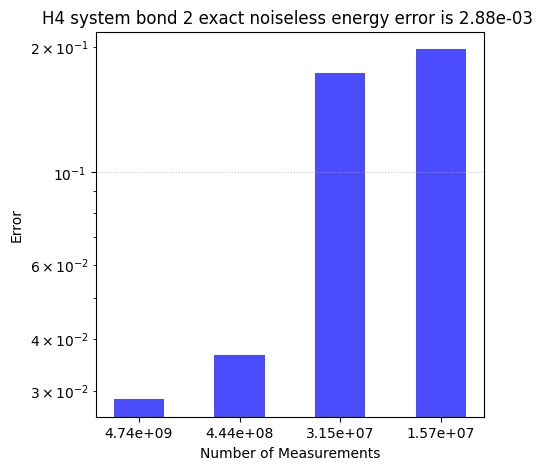

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plot_error_list = np.array([2.864156509438e-02,3.652653888069e-02,1.732138349527e-01,1.970507382043e-01])

# add noise into optim at different noise level,
# 1.5*1e-3 error to 1048640 shots for energy
plot_num_measurement = np.array([1048640*4520,131080*3390,16385*1921,8192*1921])

plt.figure(figsize=(5, 5))
# Use evenly spaced indices for the bars so they don't overlap or clump together
x_indices = np.arange(len(plot_num_measurement))
plt.bar(x_indices, plot_error_list, color='b', alpha=0.7, width=0.5)

# Set the x-ticks to be the scientific notation strings of our actual measurements
plt.xticks(x_indices, [f"{x:.2e}" for x in plot_num_measurement])

plt.xlabel('Number of Measurements')
plt.ylabel('Error')

# Set y-axis to logarithmic scale to show 10^-1, 10^-2
plt.yscale('log')

# Only show horizontal grid lines for a bar chart
plt.grid(True, axis='y', linestyle=':', alpha=0.7)

plt.title('H4 system bond 2 exact noiseless energy error is 2.88e-03 ')
plt.show()